# Movie Recommendation System

This project builds a movie recommendation system using collaborative filtering. 
The model analyzes user ratings to identify similar movies and recommend films a user may enjoy.

Dataset: MovieLens 32M

Steps: 
1. Load and clean the data
2. Perform exploratory data analysis
3. Build a movie-user rating matrix
4. Compute cosine similarity between movies
5. Generate movie recommendations

## Import Libraries

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import csr_matrix

## Load Dataset

In [ ]:
movies = pd.read_csv(f"/Users/amru/Documents/GitHub/Movie_Recommendation/data/movies.csv")
ratings = pd.read_csv(f"/Users/amru/Documents/GitHub/Movie_Recommendation/data/ratings.csv")

movies.head(), ratings.head()

print("Movies info:")
movies.info()
print("\nRatings info:")
ratings.info()

## Data Cleaning

In [ ]:
df = ratings.merge(movies, on="movieId")

print("Merged DataFrame shape:", df.shape)
df.head()

## Filtering Movies With Enough Ratings

In [ ]:
# count the number of ratings per movie
movie_ratings = df.groupby("title")["rating"].count().sort_values(ascending=False)
movie_ratings.head(10)

# filter the movies by rating
popular_movies = movie_ratings[movie_ratings >= 5000].index
filtered_df = df[df["title"].isin(popular_movies)]

#check if the filtering works
print("Original shape:", df.shape)
print("Filtered shape:", filtered_df.shape)
print("Number of unique movies after filtering:", filtered_df["title"].nunique())

## Exploratory Data Analysis

### Rating Distribution

In [ ]:
# we will use the filtered data frame

#how are ratings distributed?
# are users biased towards higher ratings?

# is the dataset skewed?
# the dataset is skewed positively = 
# observation is users tend to rate movies 
# they like rather than movies they dislike

plt.figure(figsize=(8,5))
sns.histplot(filtered_df["rating"], bins=10, kde=True)
plt.title("Distribution of Movie Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

### Most Rated Movies

In [ ]:
#which movies get the most ratings?
# does popularity correlate with rating quality?

#average rating per movie
movie_stats = filtered_df.groupby("title").agg({
    "rating": ["mean", "count"]
})
movie_stats.columns = ["average_rating", "rating_count"]
movie_stats = movie_stats.sort_values("rating_count", ascending=False)
movie_stats.head(10)

### Popularity vs Average Rating

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x = "rating_count",
    y = "average_rating",
    data = movie_stats,
    alpha = 0.5
)

plt.title("Average Rating vs Number of Ratings")
plt.xlabel("Number of Ratings")
plt.ylabel("Average Rating")
plt.show()

### Genre Analysis

In [ ]:
# split genres into their own rows
genre_df = filtered_df.copy()
genre_df["genres"] = genre_df["genres"].str.split("|")
genre_split = genre_df.explode("genres")

genre_split.head()

In [ ]:
genre_counts = genre_split["genres"].value_counts()

plt.figure(figsize=(10,6))
sns.barplot(x=genre_counts.values, y=genre_counts.index)
plt.title("Number of Ratings per Genre")
plt.xlabel("Number of Ratings")
plt.ylabel("Genre")
plt.show()

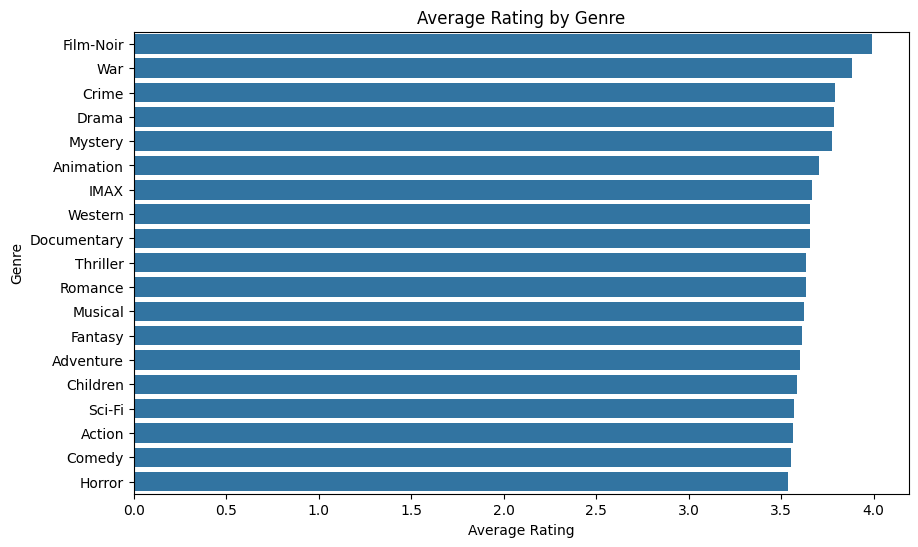

genres
Film-Noir    3.989907
War          3.884388
Crime        3.792837
Drama        3.784358
Mystery      3.776606
Name: rating, dtype: float64

In [19]:
genre_avg = genre_split.groupby("genres")["rating"].mean().sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=genre_avg.values, y=genre_avg.index)
plt.title("Average Rating by Genre")
plt.xlabel("Average Rating")
plt.ylabel("Genre")
plt.show()

genre_avg.head()

## Feature Engineering

In [28]:
filtered_df["year"] = filtered_df["title"].str.extract(r"\((\d{4})\)").astype(float)
filtered_df[["title", "year"]].head()

year_avg = filtered_df.groupby("year")["rating"].mean()
plt.figure(figsize=(10,6))
year_avg.plot()
plt.title("Average Movie Rating Over Time")
plt.xlabel("Year")
plt.ylabel("Average Rating")
plt.show()

KeyboardInterrupt: 

## Create Movie-User Matrix

In [ ]:
# movie user matrix

movie_user_matrix = filtered_df.pivot_table(
    index="title",
    columns="userId",
    values="rating"
)

print("Matrix shape:", movie_user_matrix.shape)
movie_user_matrix.head()

## Compute Cosine Similarity

In [ ]:
# replace NaNs with 0s
movie_user_matrix_filled = movie_user_matrix.fillna(0)

#compressing sparse data to save memory
movie_sparse = csr_matrix(movie_user_matrix_filled.values)

#measures similarity between movies
movie_similarity = cosine_similarity(movie_sparse)

print("Similarity matrix shape:", movie_similarity.shape)

## Movie Index Mapping

In [ ]:
# mapping of movie title to matrix index
movie_indices = pd.Series( 
    index=movie_user_matrix.index,
    data=range(len(movie_user_matrix))
)

movie_indices.head()

## Movie Recommendation Function

This functions finds movies that are most similar to the input title using the cosine similarity.

In [ ]:
def recommend_movies(title, similarity_matrix = movie_similarity, n=5):
    #case sensitives
    matches = [movie for movie in movie_user_matrix.index if title.lower() in movie.lower()]

    if len(matches) == 0:
        return "Movie not found in dataset."



    selected_movie = matches[0]
    idx = movie_indices[selected_movie]

    similarity_scores = list(enumerate(similarity_matrix[idx]))

    #sort by similarity descending
    similarity_scores = sorted(similarity_scores, key=lambda x: x[1], reverse=True)
    
    #exclude the movie itself
    similarity_scores = similarity_scores[1:n+1]
    movie_titles = [movie_user_matrix.index[i[0]] for i in similarity_scores]

    return movie_titles


In [26]:
def show_recommendations(title, n=5):
    
    recs = recommend_movies(title, n=n)
    
    if isinstance(recs, str):
        print(recs)
        return
    
    print(f"\nMovies similar to '{title}':\n")
    
    for i, movie in enumerate(recs, 1):
        print(f"{i}. {movie}")

## Example Recommendations

In [27]:
show_recommendations("godfather")
show_recommendations("toy story")
show_recommendations("dark knight")
show_recommendations("shawshank")


Movies similar to 'godfather':

1. Godfather: Part II, The (1974)
2. Goodfellas (1990)
3. Pulp Fiction (1994)
4. One Flew Over the Cuckoo's Nest (1975)
5. Shawshank Redemption, The (1994)

Movies similar to 'toy story':

1. Toy Story 2 (1999)
2. Star Wars: Episode IV - A New Hope (1977)
3. Back to the Future (1985)
4. Forrest Gump (1994)
5. Jurassic Park (1993)

Movies similar to 'dark knight':

1. Dark Knight, The (2008)
2. Inception (2010)
3. Avengers, The (2012)
4. Batman Begins (2005)
5. Django Unchained (2012)

Movies similar to 'shawshank':

1. Pulp Fiction (1994)
2. Forrest Gump (1994)
3. Silence of the Lambs, The (1991)
4. Schindler's List (1993)
5. Usual Suspects, The (1995)


## Conclusion

In this project we built a collaborative filtering movie recommendation system using cosine similarity.

Key steps included:
- Cleaning the MovieLens dataset
- Performing exploratory data analysis
- Building a movie-user rating matrix
- Computing similarity between movies

The system successfully recommends movies based on user rating patterns.

Future improvements could include:
- Using matrix factorization (SVD)
- Adding content-based filtering
- Building a web interface for users